# CS171 Project
## Trash Sorting RCNN

**Author** - Helena Thiessen

**Date** - Nov 20/25

### Motivation
Creating and finetuning an RCNN that can identify trash and recycling.

In [31]:
!pip install opencv-python
!pip install torchmetrics[detection]

In [32]:
import torch
import torch.nn as nn
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from torchvision.ops import nms
import itertools
from torch.utils.data import random_split
import json
import torchvision
from torchvision.models._utils import IntermediateLayerGetter
from torchvision.ops.feature_pyramid_network import FeaturePyramidNetwork, LastLevelMaxPool

In [33]:
import cv2
from torchmetrics.detection import MeanAveragePrecision
from torchvision.ops import MultiScaleRoIAlign

import os

In [34]:
%run preprocess.ipynb

Using device: cpu


# To do
- normalize
- transforms
- schedulers
- optimizers
- tune backbone/ research rcnn backbones
- validation set
- possibly switch datasets (taco or warp?)
- possibly make preprocess an import instead of a run
- make val set
- clean up, comment, functionize

## Creating an RCNN Model

## Training on Warp Dataset

In [35]:
def collate_fn(batch):
    imgs, targets = list(zip(*batch))
    return list(imgs), list(targets)

root = Path.cwd() / "Warp-D"

train_ds = RCNN_Warp_Data(root, split="train")
test_ds  = RCNN_Warp_Data(root, split="test")

train_loader = DataLoader(
    train_ds,
    batch_size=2,           
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

In [36]:
##temporary replacement for above cell
train_ds = RCNN_Warp_Data(root, split="train")
test_ds  = RCNN_Warp_Data(root, split="test")

sub_size = 0.1
train_size = int(sub_size * len(train_ds))
test_size = int(sub_size * len(test_ds))

train_ds, _ = random_split(train_ds, [train_size, len(train_ds) - train_size]) 
test_ds, _ = random_split(test_ds, [test_size, len(test_ds) - test_size]) 


train_loader = DataLoader(
    train_ds,
    batch_size=2,           
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

In [37]:
class Custom_Backbone(nn.Module):
    def __init__(
        self,
        resnet='resnet50',
        weights='DEFAULT',            
        trainable_layers=3,          
        returned_layers=(2, 3, 4),    
        in_channels_list=(512, 1024, 2048),
        out_channels=256,
        norm_layer=nn.BatchNorm2d
    ):
        super().__init__()

        # Version-safe weights handling
        def _get_resnet(resnet_name, weights_flag, norm_layer):
            ctor = getattr(torchvision.models, resnet_name)
            # Try new API first
            try:
                weights_arg = None
                if weights_flag == 'DEFAULT':
                    enum = getattr(torchvision.models, f"{resnet_name}_Weights", None)
                    if enum is not None:
                        weights_arg = enum.DEFAULT
                return ctor(weights=weights_arg, norm_layer=norm_layer)
            except TypeError:
                # Old API: pretrained=bool
                return ctor(pretrained=(weights_flag == 'DEFAULT'), norm_layer=norm_layer)

        base = _get_resnet(resnet, weights, norm_layer)

        layers_to_train = ['layer4', 'layer3', 'layer2', 'layer1', 'conv1']
        for i, name in enumerate(layers_to_train):
            if i >= trainable_layers:
                module = getattr(base, name, None)
                if module is not None:
                    for p in module.parameters():
                        p.requires_grad = False


        return_layers = {f"layer{l}": f"C{l+1}" for l in returned_layers}  
        self.body = IntermediateLayerGetter(base, return_layers=return_layers)

        self.fpn = FeaturePyramidNetwork(
            in_channels_list=list(in_channels_list),
            out_channels=out_channels,
            extra_blocks=LastLevelMaxPool(), 
        )

        self.out_channels = out_channels

    def forward(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        c_feats = self.body(x)        
        p_feats = self.fpn(c_feats)   
        return p_feats

In [38]:
def training_loop(model, optimizer, NUM_EPOCHS, train_loader, test_loader, printing=True): 
    test_metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
    train_metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
    test_maps = []
    train_losses = []
    train_maps = []
    
    for epoch in range(NUM_EPOCHS):
        
        # Run the training loop
        model.train()
        total_train_loss = 0.0

        for train_inputs, train_labels in train_loader:
            train_inputs = list(image.to(device) for image in train_inputs)
            train_labels = [{k: v.to(device) for k, v in t.items()} for t in train_labels]

            
            optimizer.zero_grad()
            train_loss_dict = model(train_inputs, train_labels)
            loss = sum(train_loss_dict.values())
            
            loss.backward()
            optimizer.step()

            model.eval()
            with torch.no_grad():
                preds = model(train_inputs)  # Now it returns predictions
                train_metric.update(preds, train_labels)
            model.train()

            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        train_map_results = train_metric.compute()
        train_maps.append(train_map_results['map'])

        

        # Run the testing loop
        # this is essentially the same as the training loop but
        # without the optimizer and backward propagation
        #model.eval()
        total_test_loss = 0.0
        model.eval()
        with torch.no_grad():
            for test_inputs, test_labels in test_loader:
                test_inputs = list(image.to(device) for image in test_inputs)
                test_labels = [{k: v.to(device) for k, v in t.items()} for t in test_labels]
                
                predictions = model(test_inputs)
                test_metric.update(predictions, test_labels)
            #     loss = sum(test_loss_dict.values())
            
            #     total_test_loss += loss.item()
            test_map_results = test_metric.compute()
            # avg_test_loss = total_test_loss / len(test_loader)
            test_maps.append(test_map_results['map'])
            test_metric.reset()

        if printing:
            print(f"Epoch {epoch+1}/{NUM_EPOCHS}"+\
                  f" - Train Loss: {avg_train_loss:.4f} ", end = " ")
            print(f"- Train Map {train_map_results['map'].item():.4f}", end = " ")
            print(f"- Test  Map {test_map_results['map'].item():.4f}")

    return train_losses,test_maps, train_maps

In [39]:
backbone = Custom_Backbone(
        resnet='resnet50',
        weights='DEFAULT',
        trainable_layers=3,              
        returned_layers=(2,3,4),         
        in_channels_list=(512,1024,2048),
        out_channels=256
)

anchor_generator = AnchorGenerator(
    sizes=((32,), (64,), (128,), (256,)),
    aspect_ratios=((0.5, 1.0, 2.0),) * 4
)

model = FasterRCNN(backbone, num_classes=29, rpn_anchor_generator=anchor_generator).to(device)
    
model.roi_heads.box_roi_pool = MultiScaleRoIAlign(
    featmap_names=['C3', 'C4', 'C5', 'pool'],  # <— MUST match your FPN keys
    output_size=7,
    sampling_ratio=2
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_losses, test_maps, train_maps = training_loop(
        model, optimizer, NUM_EPOCHS=50,
        train_loader=train_loader, test_loader=test_loader, printing=True
)

KeyboardInterrupt: 

### Visualize results warp

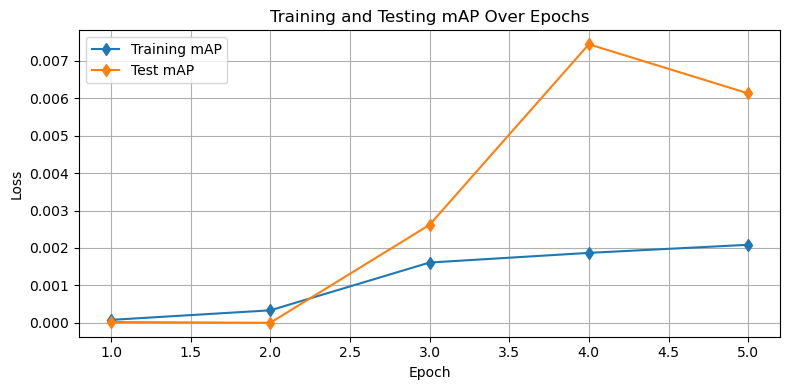

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_map, 'd-', label='Training mAP')
plt.plot(range(1, NUM_EPOCHS + 1), test_map, 'd-', label='Test mAP')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing mAP Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

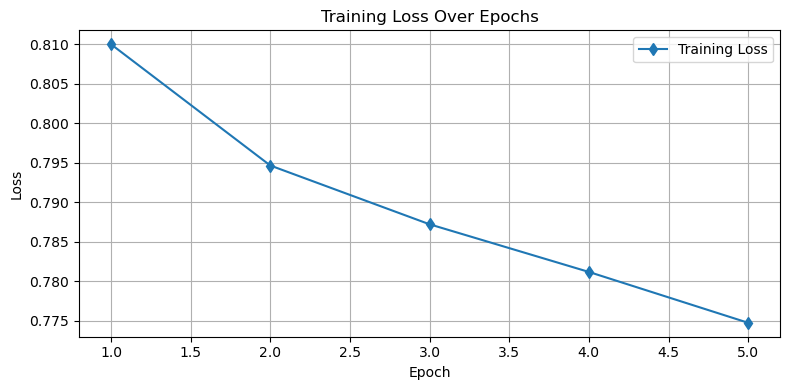

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, 'd-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
images, targets = next(iter(test_loader))

images_tens  = [im.to(device) for im in images]

pred = model(images_tens)

drawBoxes(images, targets, pred)

UnboundLocalError: cannot access local variable 'boxes_t' where it is not associated with a value